# [4] Band Stacking + Clipping

> Making use of H3 global grid indexing when working with rasters. For this example series, we focus on B04 (red), B03 (green), B02 (blue), and B08 (nir).

__Notes:__

* DBR 17.3 used
* For all of Alaska, this notebook was run on AWS [r6id.2xlarge](https://aws.amazon.com/ec2/instance-types/r6i/) instances (20 workers)[[pricing](https://www.databricks.com/product/pricing/product-pricing/instance-types)] (__you can go smaller number of workers for a single county__)

---
__Last Update:__ April 17, 2026

## Imports + Config

In [0]:
%run ./config_nb

__Libraries__

* GeoBrix assumed already installed on the cluster.
* Python bindings now are `databricks.labs.gbx.rasterx` (etc).
* Pandas now at 2.2.3 with DBR17.3
* Match GDAL to version installed with natives (3.11.4).

__Unity Catalog__

* Replace `catalog_name` and `schema_name` with your preferred locations.
* Volume 'data' must exist under `catalog_name`/`schema_name`.

/databricks/python_shell/lib/lsp_backend/line_magic_sanitizer.py:98: UserWarning: `make_tokens_by_line` received a list of lines which do not have lineending markers ('\n', '\r', '\r\n', '\x0b', '\x0c'), behavior will be unspecified
  tokens = make_tokens_by_line(lines)


Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


... catalog: 'geospatial_docs' (USE)
... schema: 'eo_series' (CREATE / USE)


... ETL_DIR: '/Volumes/geospatial_docs/eo_series/data'
... EO_DIR: '/Volumes/geospatial_docs/eo_series/data/alaska' (MKDIRS)


## Data load

> _We are focusing on the gridded tables for band stacking and NDVI._

__Note:__ Since NDVI is pixel-by-pixel, the hex clipping is not of concern. For other operations, we might do more square re-tiling.

In [0]:
%sql show tables

database,tableName,isTemporary
eo_series,band_b02,false
eo_series,band_b02_h3,false
eo_series,band_b02_tile,false
eo_series,band_b03,false
eo_series,band_b03_h3,false
eo_series,band_b03_tile,false
eo_series,band_b04,false
eo_series,band_b04_h3,false
eo_series,band_b04_tile,false
eo_series,band_b08,false


In [0]:
df_b02_h3 = spark.read.table("band_b02_h3")
df_b03_h3 = spark.read.table("band_b03_h3")
df_b04_h3 = spark.read.table("band_b04_h3")
df_b08_h3 = spark.read.table("band_b08_h3")

## Band Stacking

> We are going to merge bands into rasters from the same h3 cells.

_[1] Consolidate to 1 tile per H3 cell per day with `rst_merge_agg` aggregate function._ __Note: the following shows the multiple tiles in some cells.__

In [0]:
display(
  df_b02_h3.groupBy("cellid", "date", "band_name")
    .count()
  .orderBy(F.desc("count"))
  .limit(5)
)

cellid,date,band_name,count
608314964842643455,2022-06-01,B02,8
608314919275724799,2022-06-01,B02,8
608314920265580543,2022-06-01,B02,7
608314920399798271,2022-06-01,B02,7
608314920248803327,2022-06-01,B02,7


In [0]:
df_b02_resolved = df_b02_h3.groupBy("cellid", "date", "band_name")\
  .agg(rx.rst_merge_agg("tile").alias("tile"))

df_b03_resolved = df_b03_h3.groupBy("cellid", "date", "band_name")\
  .agg(rx.rst_merge_agg("tile").alias("tile"))

df_b04_resolved = df_b04_h3.groupBy("cellid", "date", "band_name")\
  .agg(rx.rst_merge_agg("tile").alias("tile"))

df_b08_resolved = df_b08_h3.groupBy("cellid", "date", "band_name")\
  .agg(rx.rst_merge_agg("tile").alias("tile"))

_Here is example of the resolved output._

In [0]:
print(f"band 02 resolved count? {df_b02_resolved.count():,}")
df_b02_resolved.limit(1).show(vertical=True) # <- show + limiting for ipynb only

band 02 resolved count? 21,268
-RECORD 0-------------------------
 cellid    | 608314989001834495   
 date      | 2022-06-01           
 band_name | B02                  
 tile      | {6083149890018344... 



_[2] Band stack per H3 tile; in this case, red, green, blue, and nir (4 bands)._

_[a] Here is a brief example of using union and window to stack by (ordered) band_name, using one of the cellids from above._

In [0]:
stack_win = Window.partitionBy("cellid","date").orderBy('band_name')
cellid_stack = 608314919275724799

(
  df_b02_resolved
    .withColumn("tile", rx.rst_initnodata("tile"))
    .filter(f"cellid = {cellid_stack}")
  .union(
    df_b03_resolved
      .withColumn("tile", rx.rst_initnodata("tile"))
      .filter(f"cellid = {cellid_stack}")
  )
  .union(
    df_b04_resolved
      .withColumn("tile", rx.rst_initnodata("tile"))
      .filter(f"cellid = {cellid_stack}")
  )
  .union(
    df_b08_resolved
      .withColumn("tile", rx.rst_initnodata("tile"))
      .filter(f"cellid = {cellid_stack}")
  )
  .select(
    "date",
    F
      .collect_list("tile")
        .over(stack_win)
      .alias("tiles")
  )
  .filter("array_size(tiles) = 4")
  .withColumn("tile", rx.rst_frombands("tiles"))
  .withColumn("memsize", rx.rst_memsize("tile"))
  .withColumn("num_bands", rx.rst_numbands("tile"))
).limit(1).show(vertical=True) # <- show + limiting for ipynb only

-RECORD 0-------------------------
 date      | 2022-06-01           
 tiles     | [{608314919275724... 
 tile      | {6083149192757247... 
 memsize   | 254398               
 num_bands | 4                    



_[b] Here is the main example, where we join new columns for each band to generate a stacked raster (in the order we choose)._

> Hint: joins default to inner, if you want something different add arg 'how'.

In [0]:
stack_tbl_name = "band_stack"
# sql(f"""drop table if exists {stack_tbl_name}""") # <- uncomment to drop
if not spark.catalog.tableExists(stack_tbl_name):
  try:
    repartition_factor = 100 # <- num tiles per task
    orig_repart_num = spark.conf.get("spark.sql.shuffle.partitions")
    spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", False)
    repart_num = round(df_b02_resolved.count() / repartition_factor)
    spark.conf.set("spark.sql.shuffle.partitions", repart_num)
    print(f"\t...shuffle partitions to {repart_num} for this operation.")
    (
      df_b02_resolved
        .drop("band_name")
        .withColumn("tile", rx.rst_initnodata("tile"))
        .withColumnRenamed("tile", "b02")
        .withColumn("blue_size", rx.rst_memsize("b02"))
        .sort(F.rand()) # <- forces to shuffle partition setting
        .join(
          df_b03_resolved
            .drop("band_name")
            .withColumn("tile", rx.rst_initnodata("tile"))
            .withColumnRenamed("tile", "b03")
            .withColumn("green_size", rx.rst_memsize("b03"))
            .sort(F.rand()), # <- forces to shuffle partition setting
          on = ["cellid", "date"]
        )
        .join(
          df_b04_resolved
            .drop("band_name")
            .withColumn("tile", rx.rst_initnodata("tile"))
            .withColumnRenamed("tile", "b04")
            .withColumn("red_size", rx.rst_memsize("b04"))
            .sort(F.rand()), # <- forces to shuffle partition setting
          on = ["cellid", "date"]
        )
        .join(
          df_b08_resolved
            .drop("band_name")
            .withColumn("tile", rx.rst_initnodata("tile"))
            .withColumnRenamed("tile", "b08")
            .withColumn("nir_size", rx.rst_memsize("b08"))
            .sort(F.rand()), # <- forces to shuffle partition setting
          on = ["cellid", "date"]
        )
        .withColumn("tile", rx.rst_frombands(F.array("b04","b03","b02","b08"))) 
        .withColumn("memsize", rx.rst_memsize("tile"))
        .withColumn("num_bands", rx.rst_numbands("tile"))
        .drop("b04", "b03", "b02", "b08")
      .write
      .saveAsTable(stack_tbl_name)
    )
  finally:
    # print(f"...setting shuffle partitions back to {orig_repart_num}")
    spark.conf.set("spark.sql.shuffle.partitions", orig_repart_num)
  
sql(f"""ALTER TABLE {stack_tbl_name} CLUSTER BY (cellid)""")
sql(f"""OPTIMIZE {stack_tbl_name}""")

stacked_df = spark.table(stack_tbl_name)
print(f"count? {stacked_df.count():,}")
stacked_df.limit(1).show(vertical=True) # <- show + limiting for ipynb only

count? 21,268
-RECORD 0--------------------------
 cellid     | 608314794335797247   
 date       | 2022-06-01           
 blue_size  | 45570                
 green_size | 48463                
 red_size   | 47896                
 nir_size   | 53784                
 tile       | {6083147943357972... 
 memsize    | 218805               
 num_bands  | 4                    



In [0]:
import json
json.loads(stacked_df.filter("cellid = 608311875855187967").select(rx.rst_summary("tile")).first()[0])

{'description': '/vsimem/temp_raster_ab7142fa_1932_4e53_af80_87369c0bf8a4.vrt',
 'driverShortName': 'GTiff',
 'driverLongName': 'GeoTIFF',
 'files': ['/vsimem/temp_raster_ab7142fa_1932_4e53_af80_87369c0bf8a4.vrt'],
 'size': [232, 256],
 'coordinateSystem': {'wkt': 'PROJCRS["WGS 84 / UTM zone 9N",\n    BASEGEOGCRS["WGS 84",\n        DATUM["World Geodetic System 1984",\n            ELLIPSOID["WGS 84",6378137,298.257223563,\n                LENGTHUNIT["metre",1]]],\n        PRIMEM["Greenwich",0,\n            ANGLEUNIT["degree",0.0174532925199433]],\n        ID["EPSG",4326]],\n    CONVERSION["UTM zone 9N",\n        METHOD["Transverse Mercator",\n            ID["EPSG",9807]],\n        PARAMETER["Latitude of natural origin",0,\n            ANGLEUNIT["degree",0.0174532925199433],\n            ID["EPSG",8801]],\n        PARAMETER["Longitude of natural origin",-129,\n            ANGLEUNIT["degree",0.0174532925199433],\n            ID["EPSG",8802]],\n        PARAMETER["Scale factor at natural or

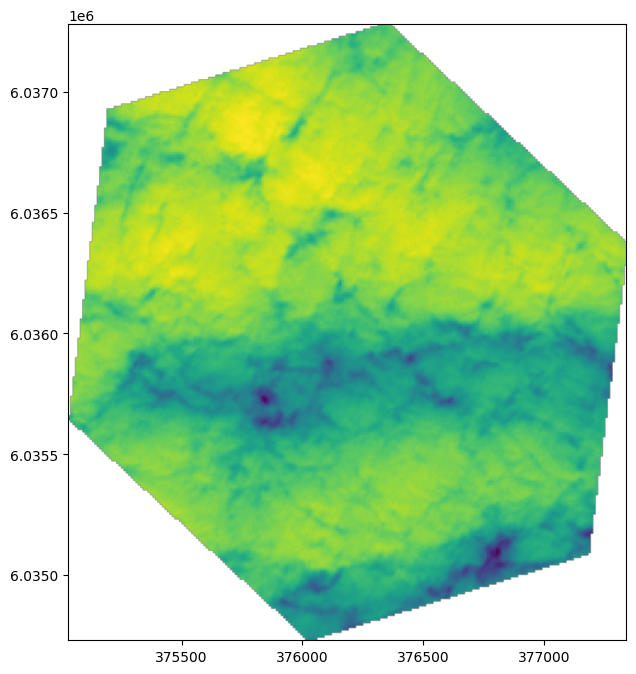

In [0]:
library.plot_raster(stacked_df.select("tile", "memsize").filter("memsize > 40000").first()["tile"]["raster"])

In [0]:
stacked_df = spark.table("band_stack")
stacked_df.limit(1).show(vertical=True) # <- show + limiting for ipynb only

-RECORD 0--------------------------
 cellid     | 608314794335797247   
 date       | 2022-06-01           
 blue_size  | 45570                
 green_size | 48463                
 red_size   | 47896                
 nir_size   | 53784                
 tile       | {6083147943357972... 
 memsize    | 218805               
 num_bands  | 4                    



_We can also write the stacked rasters out to TIF to use in various other operations._

In [0]:
STACKED_DIR = f"{EO_DIR}/out/stacked-tif"
dbutils.fs.mkdirs(STACKED_DIR)

True

In [0]:
num_stacked_files = len(dbutils.fs.ls(STACKED_DIR))
num_stacked_files

6056

In [0]:
if num_stacked_files == 0:
  (
    stacked_df
      .filter("num_bands == 4")         # <- skip missing bands
      .filter("red_size > 100000")      # <- skip small tiles
      .filter("red_size == nir_size")   # <- skip non-matching bands
      .filter(rx.rst_tryopen("tile"))   # <- skip invalid tiles
      .select("tile") # <- out table schema expects 'tile'
      .write
        .format("gdal")
        .mode("append")       # include "append" in the write 
        .option("ext", "tif") # 'tif' (default)
      .save(STACKED_DIR) 
  )
else:
  print("...skipping stacking (already have files, do you need to clean up?)")

...skipping stacking (already have files, do you need to clean up?)


## Clipping

> Here is a simple example of clipping each raster to an envelope around the centroid. More sophisticated examples might include clipping to geospatial features or providing a polygon as a spatial filter. 

In [0]:
df_clip = (
  spark.read.format("binaryFile")
  .load(STACKED_DIR)
  .withColumn("tile", rx.rst_fromcontent("content", F.lit("GTiff")))
  .filter(rx.rst_isempty("tile") == False)
  .drop("content")
  .withColumn("memsize", rx.rst_memsize("tile"))
  .withColumn("num_bands", rx.rst_numbands("tile"))
  .withColumn("metadata", rx.rst_metadata("tile"))
  .withColumn("summary", rx.rst_summary("tile"))
  .withColumn("srid", rx.rst_srid("tile"))
  .withColumn("bbox", rx.rst_boundingbox("tile"))
  .withColumn("geom", DBF.st_geomfromwkb("bbox", "srid"))          # <- DBF (built-in)
  .withColumn("centroid", DBF.st_centroid("geom"))                 # ^ 
  .withColumn("buffer", DBF.st_buffer("centroid", F.lit(100)))     # ^ 
  .withColumn("clip_wkb", DBF.st_aswkb(DBF.st_envelope("buffer"))) # ^ 
  .withColumn("clip_tile", rx.rst_clip("tile", "clip_wkb", F.lit(True)))
)

df_clip.limit(1).show(vertical=True) # <- show + limiting for ipynb only

-RECORD 0--------------------------------
 path             | dbfs:/Volumes/geo... 
 modificationTime | 2025-10-28 21:11:56  
 length           | 505368               
 tile             | {NULL, [49 49 2A ... 
 memsize          | 505368               
 num_bands        | 4                    
 metadata         | {RASTERX_CELL -> ... 
 summary          | {\n  "description... 
 srid             | 32609                
 bbox             | [00 00 00 00 03 0... 
 geom             | POLYGON((483690 6... 
 centroid         | POINT(484880 6.27... 
 buffer           | POLYGON((484980 6... 
 clip_wkb         | [01 03 00 00 00 0... 
 clip_tile        | {0, [49 49 2A 00 ... 



In [0]:
to_plot = df_clip.select("clip_tile").limit(10).collect()

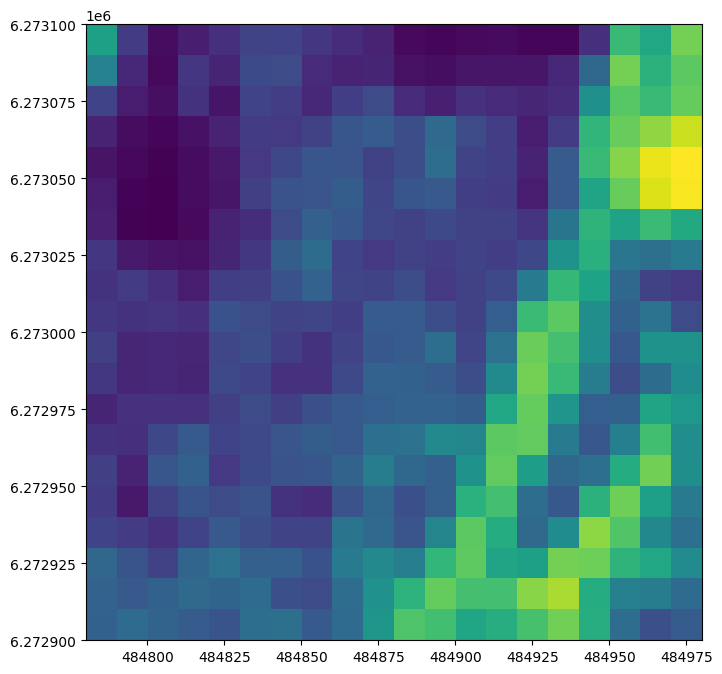

In [0]:
library.plot_raster(to_plot[0]["clip_tile"]["raster"]) # <- you may have to change the index, e.g. [15]